In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"../main_code/3d/3D_donut")
sys.path.append(r"../main_code/3d")
import generate_data3,grid_cell,adaptive_int_fix,visual,cal_S_grad,org_m,mea_3D,net_3D_fix,S_valgrad,error_general_3D,main_fix,draw,bound_detect
CUDA_LAUNCH_BLOCKING=2

def ana_S(x, center,R, r, S0):
    x1=x[:,0]
    
    x2=x[:,1]
    x3=x[:,2]
    cx, cy, cz = center[0,0],center[0,1],center[0,2]
    
    # 计算每个点相对于偏移中心是否在环形内部的条件a
    
    x_rel, y_rel, z_rel = x1 - cx, x2 - cy, x3 - cz
    condition = (np.sqrt(x_rel**2 + y_rel**2) - R)**2 + z_rel**2 <= r**2
    
    # 使用 np.where 根据条件返回 S0 或 0
    return np.where(condition, S0, 0.0)

cuda:2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
S_num_5=np.load("./noise=5%/S_num.npy")

# 创建数据
x = np.linspace(-0.5, 0.5, 301)
y = np.linspace(-0.5, 0.5, 301)
z = np.linspace(-0.5, 0.5, 301)
X, Y, Z = np.meshgrid(x, y,z,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel(),Z.ravel())).T
center_true=np.array([[0.0,0.0,0.0]])
R_true = 0.25   
r_true = 0.15
S0= 1.0 
S_true=ana_S(samples,center_true,R_true, r_true, S0).reshape(301,301,301)



In [3]:
S_num_x1_mid=S_num_5[int(0.5*S_num_5.shape[0])+1-1,:,:]
S_true_x1_mid=S_true[int(0.5*S_true.shape[0])+1-1,:,:]
S_num_x2_mid=S_num_5[:,int(0.5*S_num_5.shape[2])+1-1,:]
S_true_x2_mid=S_true[:,int(0.5*S_true.shape[2])+1-1,:]
S_num_x3_mid=S_num_5[:,:,int(0.5*S_num_5.shape[0])+1-1]
S_true_x3_mid=S_true[:,:,int(0.5*S_true.shape[0])+1-1]


In [4]:
YY,ZZ=np.meshgrid(y, z,indexing='ij')
XX,ZZ=np.meshgrid(x, z,indexing='ij')

Plot saved as ./noise=5%/visual/S_true_x1_mid.pdf


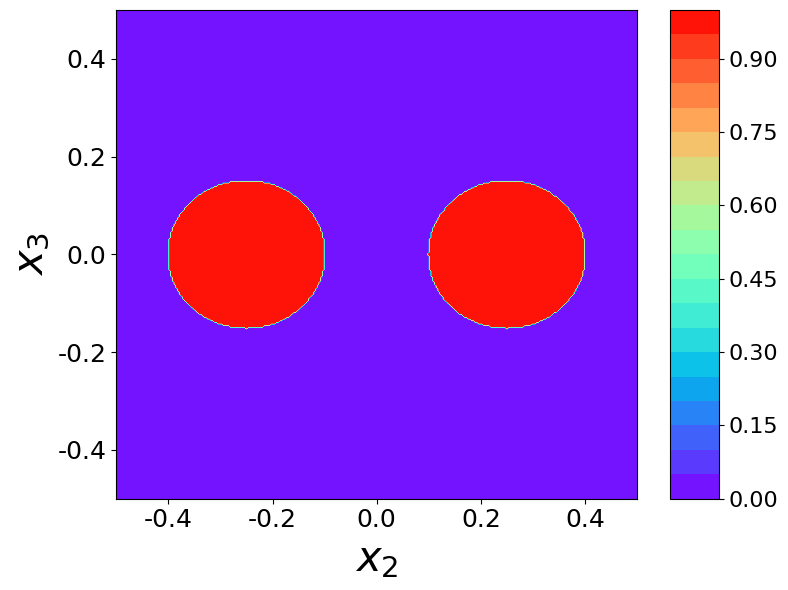

Plot saved as ./noise=5%/visual/S_num_x1_mid.pdf


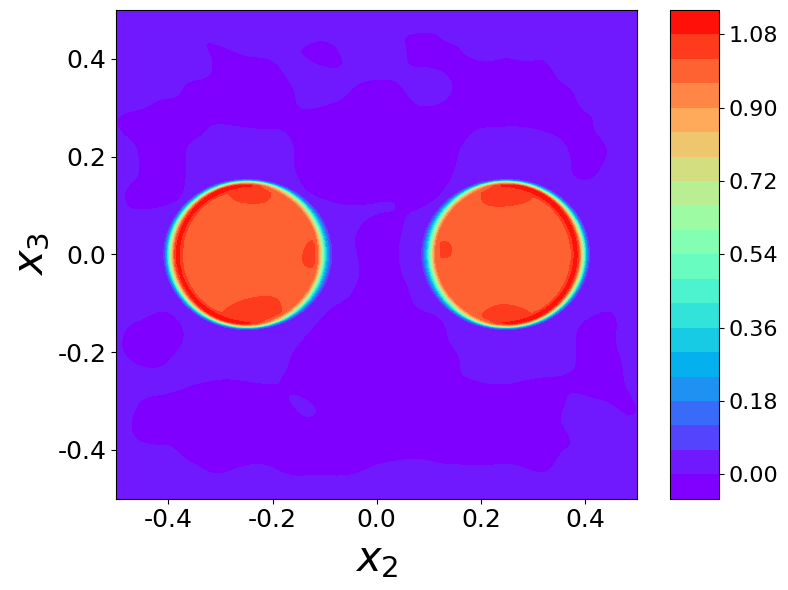

Plot saved as ./noise=5%/visual/S_true_x2_mid.pdf


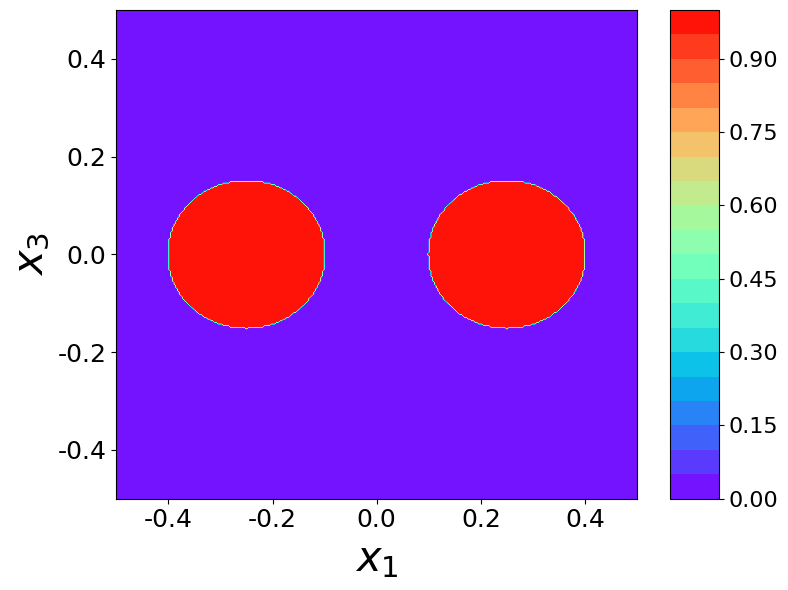

Plot saved as ./noise=5%/visual/S_num_x2_mid.pdf


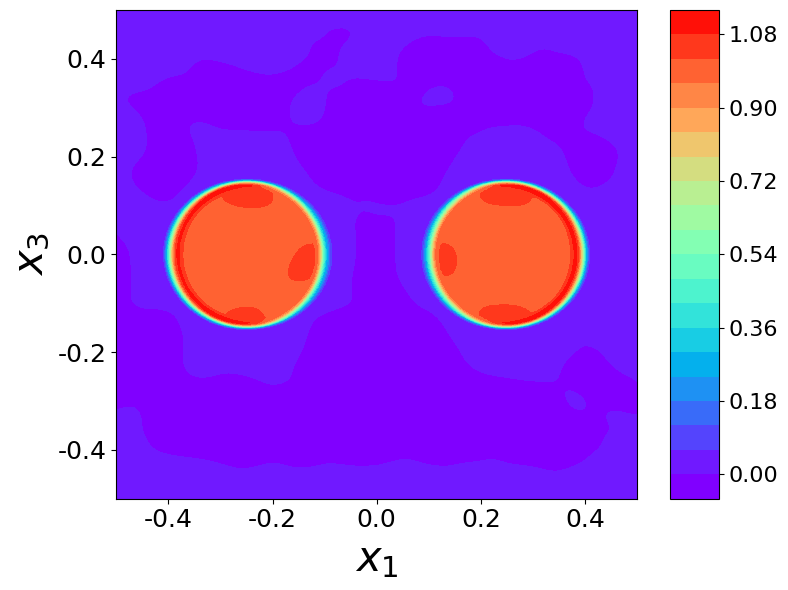

Plot saved as ./noise=5%/visual/S_true_x3_mid.pdf


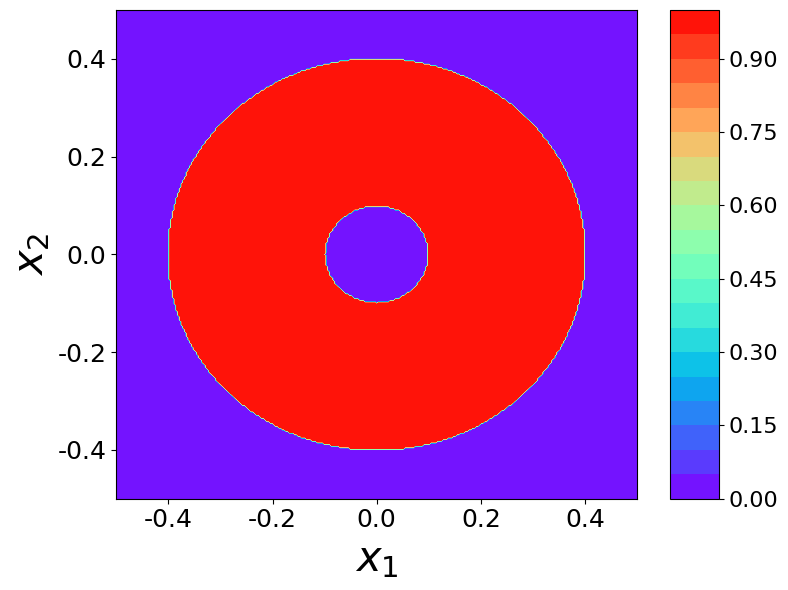

Plot saved as ./noise=5%/visual/S_num_x3_mid.pdf


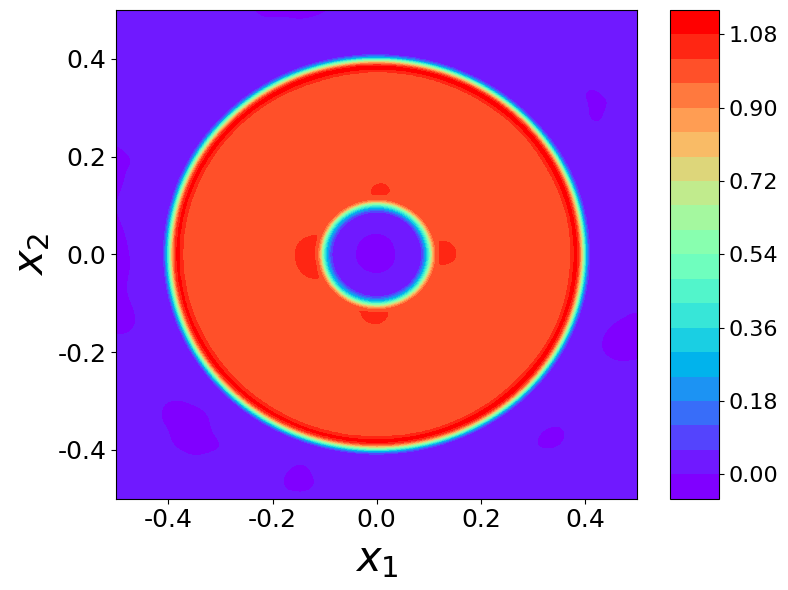

In [5]:
import Draw_3D
reload(Draw_3D)
output_dictionary="./noise=5%/visual/"
Draw_3D.draw(YY,ZZ,S_true_x1_mid,[],"$x_2$","$x_3$",[],output_dictionary,"S_true_x1_mid.pdf","")
Draw_3D.draw(YY,ZZ,S_num_x1_mid,[],"$x_2$","$x_3$",[],output_dictionary,"S_num_x1_mid.pdf","")
Draw_3D.draw(XX,ZZ,S_true_x2_mid,[],"$x_1$","$x_3$",[],output_dictionary,"S_true_x2_mid.pdf","")
Draw_3D.draw(XX,ZZ,S_num_x2_mid,[],"$x_1$","$x_3$",[],output_dictionary,"S_num_x2_mid.pdf","")
Draw_3D.draw(XX,ZZ,S_true_x3_mid,[],"$x_1$","$x_2$",[],output_dictionary,"S_true_x3_mid.pdf","")
Draw_3D.draw(XX,ZZ,S_num_x3_mid,[],"$x_1$","$x_2$",[],output_dictionary,"S_num_x3_mid.pdf","")
# draw.draw(X,Y,np.abs(S_true-S_num_5),output_dictionary,"abs_S")

In [6]:
g_S=np.load("./noise=5%/g_S.npy")
S_num_store=np.load("./noise=5%/S_num_store.npy",allow_pickle=True)

/mnt/store/hxw-y23/MA-RFM-GIT/3D_donut/./main_code/Bound_detect1.py:149: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(center_point[0], center_point[1], center_point[2], color='black', s=100, marker='x', edgecolors='black', label='Center Point', zorder=200)


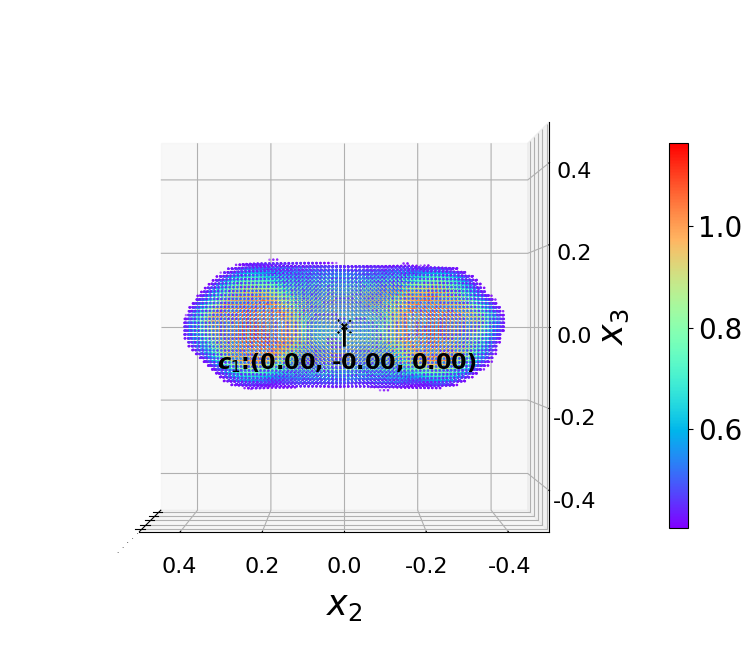

In [7]:
import Bound_detect1
reload(Bound_detect1)
dpi=100
center=np.array([[ 0.00416614, -0.00017789,  0.00138089]])
mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point= Bound_detect1.detect_3d(g_S, S_num_store[-1], [-0.5,-0.5,-0.5], [0.5,0.5,0.5], 3, 3, 0,180,center,"S",'x1',
              output_directory="./noise=5%/visual/", output_filename="plot_3d_straight.png",dpi=dpi)

/mnt/store/hxw-y23/MA-RFM-GIT/3D_donut/./main_code/Bound_detect1.py:179: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(center_point[0], center_point[1], center_point[2], color='black', s=100, marker='x', edgecolors='black', label='Center Point', zorder=200)


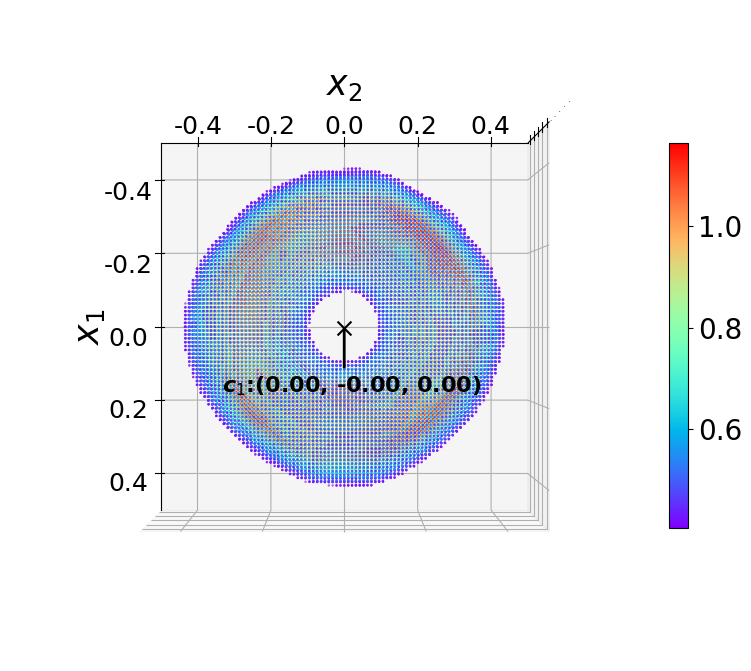

In [8]:
import Bound_detect1
reload(Bound_detect1)
center=np.array([[ 0.00416614, -0.00017789,  0.00138089]])
mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point= Bound_detect1.detect_3d(g_S, S_num_store[-1], [-0.5,-0.5,-0.5], [0.5,0.5,0.5], 3, 3, 90,0,center,"S",'x3',
              output_directory="./noise=5%/visual/", output_filename="plot_3d_top.png",dpi=dpi)

/mnt/store/hxw-y23/MA-RFM-GIT/3D_donut/./main_code/Bound_detect1.py:161: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(center_point[0], center_point[1], center_point[2], color='black', s=100, marker='x', edgecolors='black', label='Center Point', zorder=200)


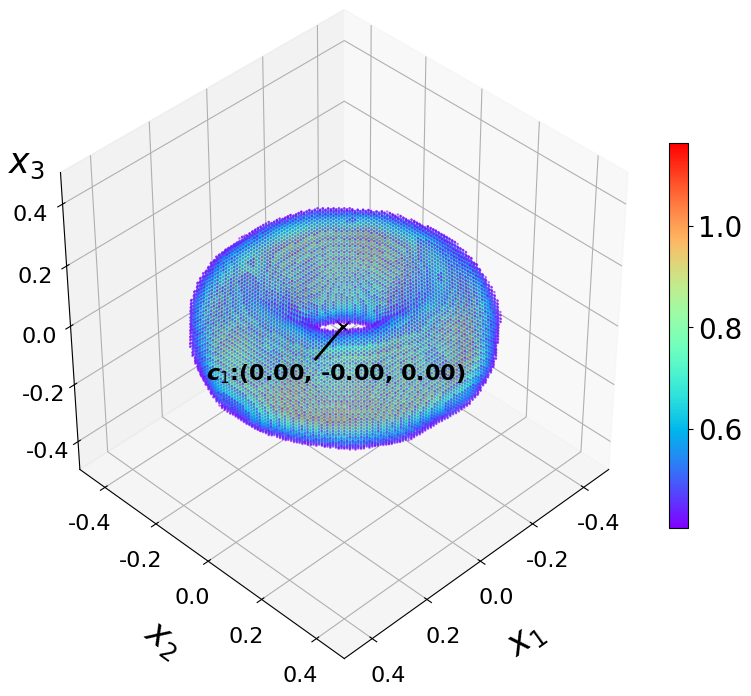

In [9]:
import Bound_detect1
reload(Bound_detect1)
center=np.array([[ 0.00416614, -0.00017789,  0.00138089]])
dpi=100
mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point= Bound_detect1.detect_3d(g_S, S_num_store[-1], [-0.5,-0.5,-0.5], [0.5,0.5,0.5], 3, 3,40,45,center,"S","x2",
              output_directory="./noise=5%/visual/", output_filename="plot_3d_tily.png",dpi=dpi)

In [10]:
S_num_1=np.load("./noise=5%/S_num.npy")
g_S1=np.load("./noise=5%/g_S1.npy")

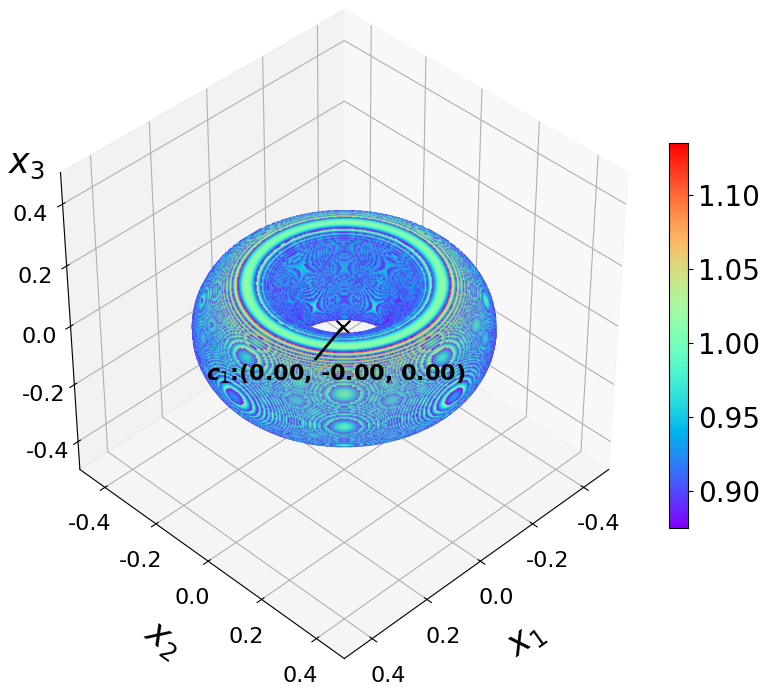

In [11]:
import Bound_detect1
reload(Bound_detect1)
center=np.array([[ 0.00416614, -0.00017789,  0.00138089]])
dpi=100
mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point= Bound_detect1.detect_3d(g_S1, S_num_1, [-0.5,-0.5,-0.5], [0.5,0.5,0.5], 20, 1.3,40,45,center,"S",'x2',
              output_directory="./noise=5%/visual/", output_filename="plot_3d_tily1.png",dpi=dpi)

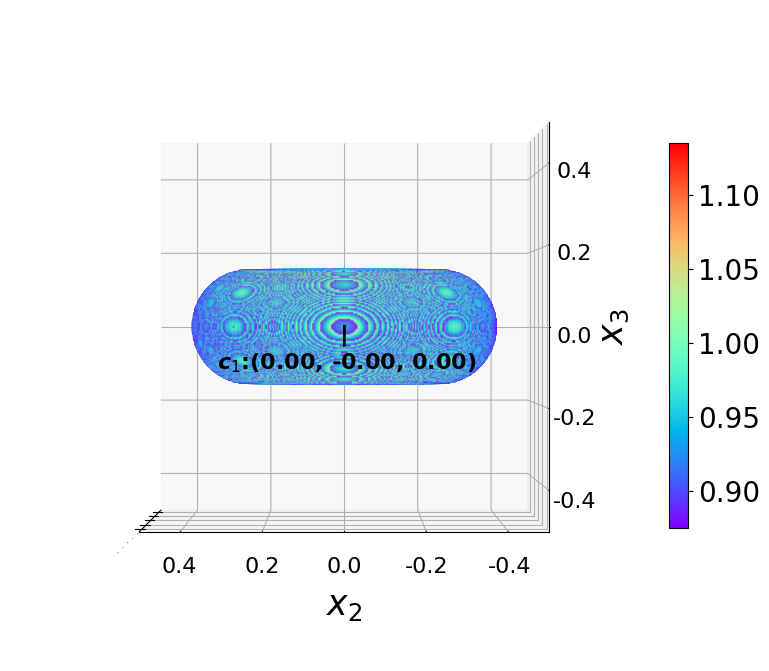

In [12]:
import Bound_detect1
reload(Bound_detect1)
center=np.array([[ 0.00416614, -0.00017789,  0.00138089]])
dpi=100
mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point= Bound_detect1.detect_3d(g_S1, S_num_1, [-0.5,-0.5,-0.5], [0.5,0.5,0.5], 20, 1.3,0,180,center,"S",'x1',
              output_directory="./noise=5%/visual/", output_filename="plot_3d_straight1.png",dpi=dpi)

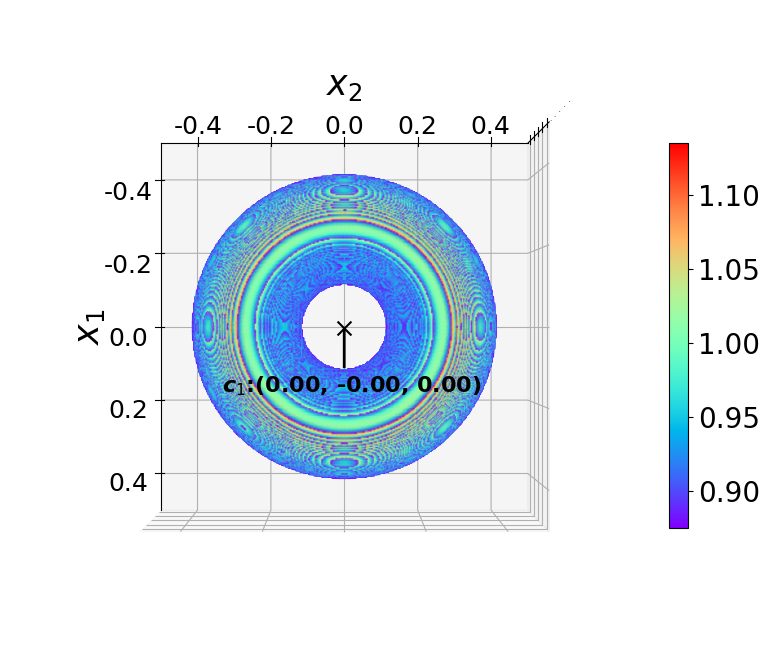

In [13]:
import Bound_detect1
reload(Bound_detect1)
center=np.array([[ 0.00416614, -0.00017789,  0.00138089]])
dpi=100
mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point= Bound_detect1.detect_3d(g_S1, S_num_1, [-0.5,-0.5,-0.5], [0.5,0.5,0.5], 20, 1.3,90,0,center,"S",'x3',
              output_directory="./noise=5%/visual/", output_filename="plot_3d_top1.png",dpi=dpi)

In [14]:
##加载cell
import pickle
with open('./noise=5%/cells_store.pkl', 'rb') as f:
    cell_stores = pickle.load(f)

Plotting 1408 cells. Levels: 1 to 2


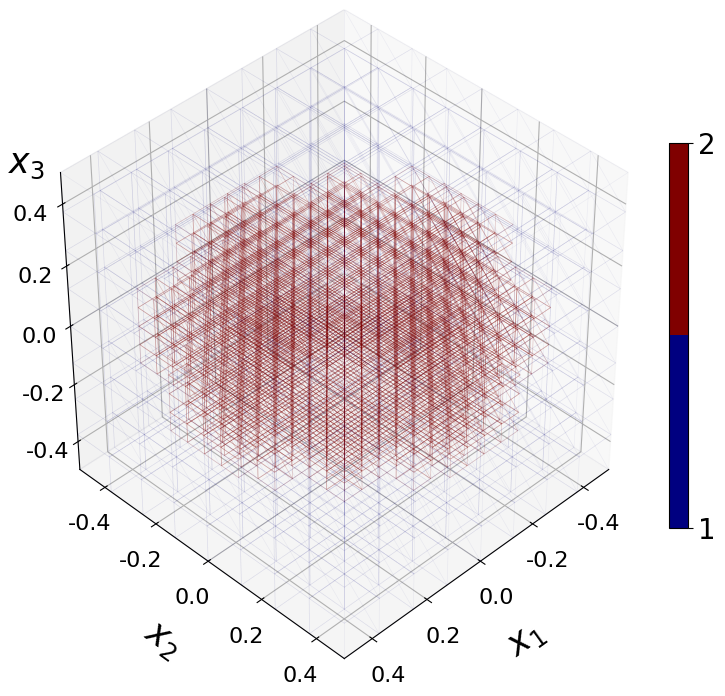

In [52]:
import Visual_cell
reload(Visual_cell)

views = [(40, 45)]
Visual_cell.visualize_3d_grid(cell_stores[-1], title="3D Adaptive Grid", views=views, alpha=0.9,noaxis="x2", output_directory="./noise=5%/visual", output_filename="cell_tily.png")

Plotting 1408 cells. Levels: 1 to 2


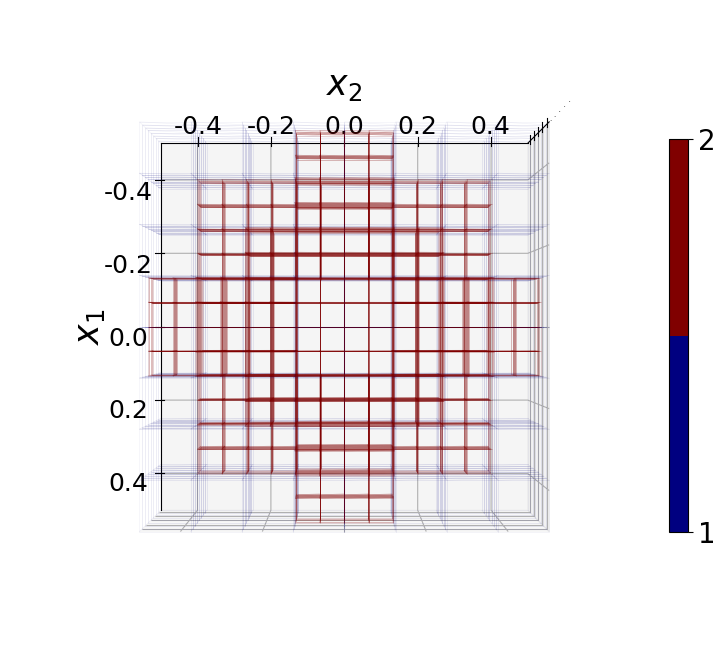

In [64]:
import Visual_cell
reload(Visual_cell)
views = [(90, 0)]
Visual_cell.visualize_3d_grid(cell_stores[-1], title="3D Adaptive Grid", views=views, alpha=0.9, noaxis="x3",output_directory="./noise=5%/visual", output_filename="cell_top.png")

Plotting 1408 cells. Levels: 1 to 2


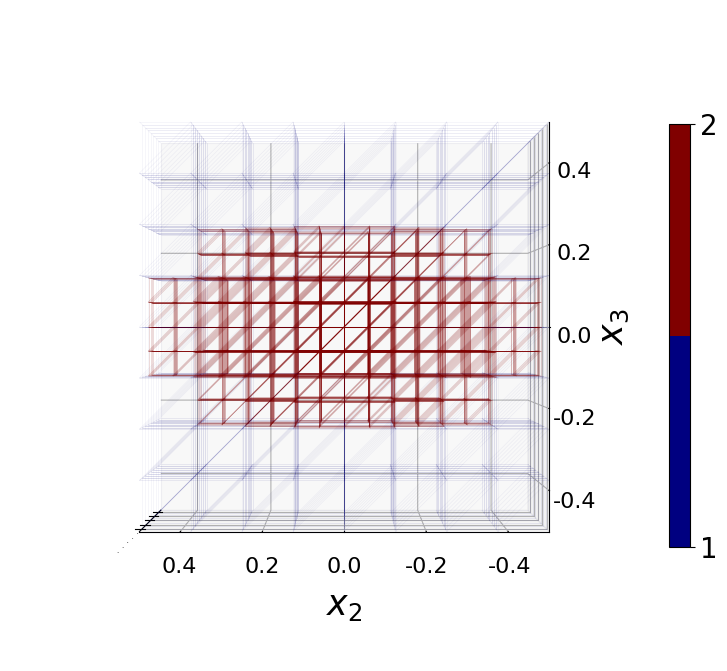

In [60]:
import Visual_cell
reload(Visual_cell)


views = [(0, 180)]
Visual_cell.visualize_3d_grid(cell_stores[-1], title="3D Adaptive Grid", views=views, alpha=0.9, noaxis="x1",output_directory="./noise=5%/visual", output_filename="cell_straight.png")